📊 Available Columns:
['Task id', 'Task', 'Details', 'Assigned', 'Starts', 'Due', 'Labels', 'Time estimate(hh:mm)', 'Time logged(hh:mm)', 'Stage', 'Progress', 'Created on', 'Created by', 'Completed on', 'Completed by', 'Main task id', 'Attachments', 'Round of Testing', 'Issue Type', 'Issue screenshot', 'Expected Screenshot', 'Page URL', 'Priority', 'Device & Browser', 'Project', 'Environment', 'Developer Name', 'Reopened count', 'Dev Comment', 'QA Comment']

✅ Cleaned Data:
   Task ID             Task Name        URL Priority  Issue Type QA Status  \
0  BUG-101    Login button issue     /login       P1          UI    closed   
1  BUG-102  Checkout API failure  /checkout       P2         API      open   
2  BUG-103            Cart issue      /cart       P3  Functional  resolved   
3  BUG-104       Payment gateway   /payment       P1  Functional     fixed   
4  BUG-105          Profile page   /profile       P2          UI    closed   

  Round  Reopen Count Start date   End Date  
0    R1

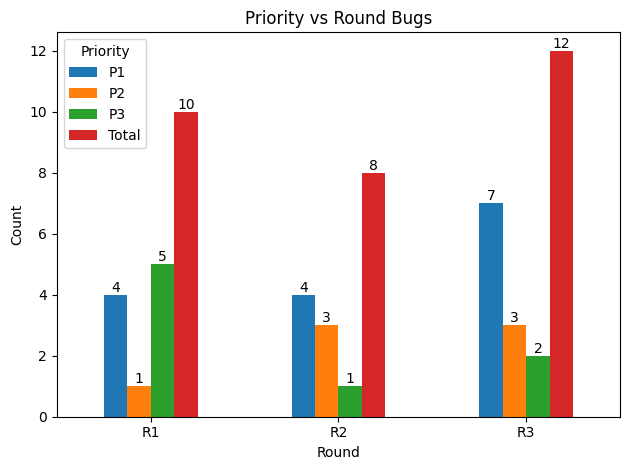


📌 Issue Type Summary:
Issue Type
UI            10
API           10
Functional     5
Magento        5
Name: count, dtype: int64


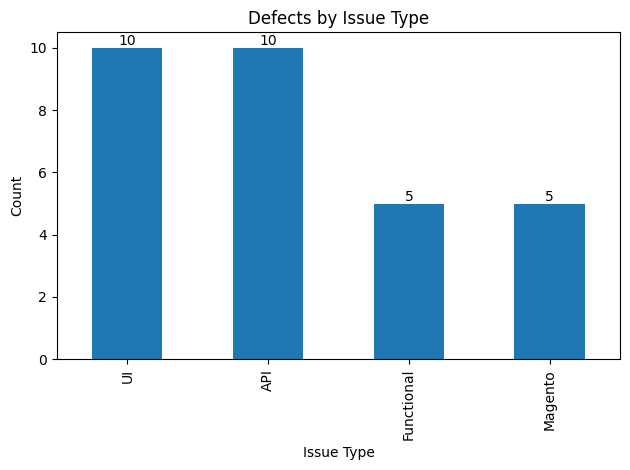


📌 Defect Aging Summary:
Priority            P1  P2  P3  Total
Closed but Delayed   5   2   1      8
Closed within SLA    2   1   3      6
Still Open           8   4   4     16
Total               15   7   8     30


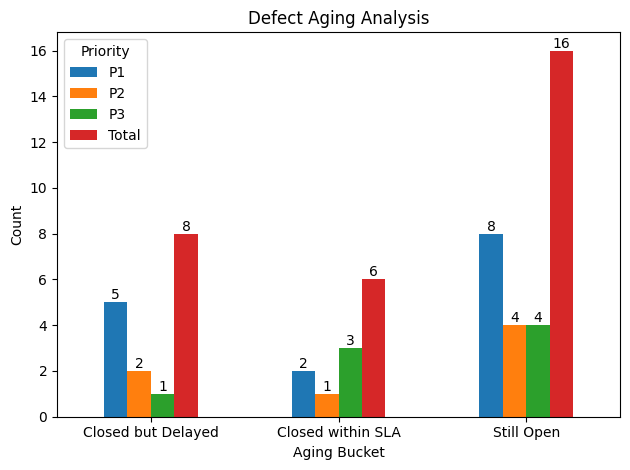


📌 Issue Type vs Priority:
Priority    P1  P2  P3  Total
API          3   4   3     10
Functional   4   0   1      5
Magento      3   0   2      5
UI           5   3   2     10
Total       15   7   8     30


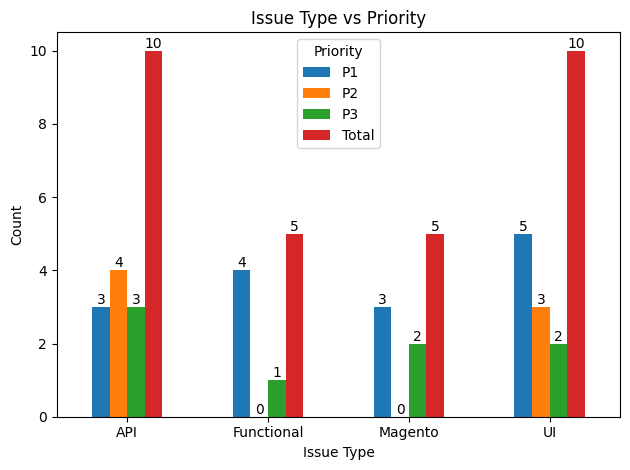

In [1]:
# =========================
# IMPORT LIBRARIES
# =========================

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from datetime import datetime

# =========================
# LOAD INPUT FILE
# =========================

INPUT_FILE = "/content/sample_tasks.xlsx"

df_raw = pd.read_excel(INPUT_FILE)

print("📊 Available Columns:")
print(df_raw.columns.tolist())

# =========================
# DATA CLEANING
# =========================

def clean_data(df_raw):

    normalized_cols = {
        str(col).strip().lower().replace(" ", "").replace("_", ""): col
        for col in df_raw.columns
    }

    required_map = {
        "taskid": "Task ID",
        "task": "Task Name",
        "pageurl": "URL",
        "priority": "Priority",
        "issuetype": "Issue Type",
        "stage": "QA Status",
        "roundoftesting": "Round",
        "reopenedcount": "Reopen Count",
        "createdon": "Start date",
        "completedon": "End Date"
    }

    data = {}

    for raw_key, standard_col in required_map.items():
        if raw_key in normalized_cols:
            data[standard_col] = df_raw[normalized_cols[raw_key]]

    df = pd.DataFrame(data)

    required_columns = [
        "Task ID",
        "Task Name",
        "URL",
        "Priority",
        "Issue Type",
        "QA Status",
        "Round",
        "Reopen Count",
        "Start date",
        "End Date"
    ]

    for col in required_columns:
        if col not in df.columns:
            df[col] = np.nan

    df = df[required_columns]

    # =========================
    # PRIORITY CLEANING
    # =========================

    df["Priority"] = (
        df["Priority"]
        .astype(str)
        .str.strip()
        .str.upper()
    )

    df["Priority"] = df["Priority"].replace({
        "HIGH": "P1",
        "CRITICAL": "P1",
        "MEDIUM": "P2",
        "LOW": "P3"
    })

    # =========================
    # ROUND CLEANING
    # =========================

    df["Round"] = (
        df["Round"]
        .astype(str)
        .str.strip()
        .str.upper()
        .str.replace("ROUND", "R")
        .str.replace(" ", "")
    )

    # =========================
    # STATUS CLEANING
    # =========================

    df["QA Status"] = (
        df["QA Status"]
        .astype(str)
        .str.strip()
        .str.lower()
    )

    # =========================
    # DATE CONVERSION
    # =========================

    df["Start date"] = pd.to_datetime(
        df["Start date"],
        errors="coerce"
    )

    df["End Date"] = pd.to_datetime(
        df["End Date"],
        errors="coerce"
    )

    # =========================
    # REOPEN COUNT CLEANING
    # =========================

    df["Reopen Count"] = pd.to_numeric(
        df["Reopen Count"],
        errors="coerce"
    ).fillna(0)

    return df


df = clean_data(df_raw)

print("\n✅ Cleaned Data:")
print(df.head())

# =========================
# PRIORITY VS ROUND ANALYSIS
# =========================

priority_round_table = pd.pivot_table(
    df,
    index="Round",
    columns="Priority",
    aggfunc="size",
    fill_value=0
)

priority_round_table["Total"] = priority_round_table.sum(axis=1)

total_row = priority_round_table.sum(axis=0)
total_row.name = "Total"

priority_round_table = pd.concat([
    priority_round_table,
    total_row.to_frame().T
])

print("\n📌 Priority vs Round Summary:")
print(priority_round_table)

priority_round_table.drop("Total").plot(kind="bar")

plt.title("Priority vs Round Bugs")
plt.xlabel("Round")
plt.ylabel("Count")
plt.xticks(rotation=0)

for container in plt.gca().containers:
    plt.bar_label(container)

plt.tight_layout()
plt.show()

# =========================
# ISSUE TYPE ANALYSIS
# =========================

df["Issue Type"] = (
    df["Issue Type"]
    .astype(str)
    .str.strip()
)

issue_type_table = df["Issue Type"].value_counts()

print("\n📌 Issue Type Summary:")
print(issue_type_table)

issue_type_table.plot(kind="bar")

plt.title("Defects by Issue Type")
plt.xlabel("Issue Type")
plt.ylabel("Count")

for container in plt.gca().containers:
    plt.bar_label(container)

plt.tight_layout()
plt.show()

# =========================
# DEFECT AGING ANALYSIS
# =========================

today = pd.Timestamp(datetime.today().date())

sla_map = {
    "P1": 1,
    "P2": 3,
    "P3": 5
}

# Aging Days Calculation

df["Aging Days"] = df.apply(
    lambda r:
    (r["End Date"] - r["Start date"]).days
    if pd.notna(r["End Date"])
    and r["QA Status"] in ["closed", "resolved", "fixed"]
    else (today - r["Start date"]).days,
    axis=1
)

# Delay Calculation

def calc_delay(row):

    sla = sla_map.get(row["Priority"], 999)

    if row["QA Status"] in [
        "closed",
        "resolved",
        "fixed"
    ]:

        delay = row["Aging Days"] - sla

        return delay if delay > 0 else 0

    return np.nan


df["Delay Days"] = df.apply(
    calc_delay,
    axis=1
)

# Aging Bucket Classification

def aging_bucket(row):

    sla = sla_map.get(row["Priority"], 999)

    if row["QA Status"] not in [
        "closed",
        "resolved",
        "fixed"
    ]:
        return "Still Open"

    elif row["Aging Days"] <= sla:
        return "Closed within SLA"

    else:
        return "Closed but Delayed"


df["Aging Bucket"] = df.apply(
    aging_bucket,
    axis=1
)

aging_summary = pd.pivot_table(
    df,
    index="Aging Bucket",
    columns="Priority",
    aggfunc="size",
    fill_value=0
)

aging_summary["Total"] = aging_summary.sum(axis=1)

total_row = aging_summary.sum(axis=0)
total_row.name = "Total"

aging_summary = pd.concat([
    aging_summary,
    total_row.to_frame().T
])

print("\n📌 Defect Aging Summary:")
print(aging_summary)

aging_summary.drop("Total").plot(kind="bar")

plt.title("Defect Aging Analysis")
plt.xlabel("Aging Bucket")
plt.ylabel("Count")
plt.xticks(rotation=0)

for container in plt.gca().containers:
    plt.bar_label(container)

plt.tight_layout()
plt.show()

# =========================
# ISSUE TYPE VS PRIORITY
# =========================

issue_priority_table = pd.pivot_table(
    df,
    index="Issue Type",
    columns="Priority",
    aggfunc="size",
    fill_value=0
)

issue_priority_table["Total"] = issue_priority_table.sum(axis=1)

total_row = issue_priority_table.sum(axis=0)
total_row.name = "Total"

issue_priority_table = pd.concat([
    issue_priority_table,
    total_row.to_frame().T
])

print("\n📌 Issue Type vs Priority:")
print(issue_priority_table)

issue_priority_table.drop("Total").plot(kind="bar")

plt.title("Issue Type vs Priority")
plt.xlabel("Issue Type")
plt.ylabel("Count")
plt.xticks(rotation=0)

for container in plt.gca().containers:
    plt.bar_label(container)

plt.tight_layout()
plt.show()